1. Data Loading & Cleaning

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


mortality = pd.read_excel("data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",sheet_name="20q5, 10q10",skiprows=14)

mortality.columns = mortality.columns.str.strip()

mortality = mortality[["Region", "Sex", "Year", "Median"]]

mortality = mortality.rename(columns={
    "Median": "mort_median_5_24"
})

mortality = mortality.groupby(["Region", "Year"])["mort_median_5_24"].mean().reset_index()

hdi = pd.read_excel(
    "data/HDR25_Statistical_Annex_HDI_Table.xlsx",
    skiprows=4,
    usecols="B:C"
)

hdi.columns = ["Country", "HDI"]
hdi = hdi.iloc[2:].reset_index(drop=True)
hdi.head()

econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=6,
    header=None,
    usecols=[1, 6, 8]
)

econ.columns = ["Country", "health_spending", "education_spending"]

econ = econ.iloc[1:].reset_index(drop=True)

econ["health_spending"] = pd.to_numeric(econ["health_spending"], errors="coerce")
econ["education_spending"] = pd.to_numeric(econ["education_spending"], errors="coerce")


mapping = pd.read_excel("data/JME_Regional-Classifications.xlsx")

mapping = mapping[["Country", "UNICEF Region"]]
mapping = mapping.rename(columns={"UNICEF Region": "UNICEF Region"})
mapping.head()



,Country,UNICEF Region
0,Afghanistan,ROSA
1,Albania,ECA
2,Algeria,MENA
3,Andorra,ECA
4,Angola,SSA


In [72]:
region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}

In [73]:
econ = econ.merge(mapping, on="Country", how="left")
econ.head()

,Country,health_spending,education_spending,UNICEF Region
0,Afghanistan,0.720916,4.34319,ROSA
1,Albania,2.884195,2.74931,ECA
2,Algeria,3.267783,6.29900,MENA
3,Andorra,6.167981,2.66623,ECA
4,Angola,1.711142,2.33200,SSA


In [74]:
hdi = hdi.merge(mapping, on="Country", how="left")
hdi.head()

,Country,HDI,UNICEF Region
0,Very high human development,NaN,NaN
1,Iceland,0.972,ECA
2,Norway,0.97,ECA
3,Switzerland,0.97,ECA
4,Denmark,0.962,ECA


In [75]:
hdi = hdi.rename(columns={"UNICEF Region": "Region"})
hdi["HDI"] = pd.to_numeric(hdi["HDI"], errors="coerce")

hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()
hdi_region.head(10)

,Region,HDI
0,EAPRO,0.735857
1,ECA,0.882796
2,LACRO,0.768424
3,MENA,0.776778
4,ROSA,0.659000
5,SSA,0.561587


In [76]:
region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}

hdi_region["Region"] = hdi_region["Region"].replace(region_map)
hdi_region

,Region,HDI
0,East Asia and Pacific,0.735857
1,Europe and Central Asia,0.882796
2,Latin America and Caribbean,0.768424
3,Middle East and North Africa,0.776778
4,South Asia,0.659000
5,Sub-Saharan Africa,0.561587


In [77]:
econ_region = econ.groupby("UNICEF Region")[["health_spending", "education_spending"]].mean().reset_index()
econ_region["UNICEF Region"] = econ_region["UNICEF Region"].replace(region_map)

econ_region.head()

,UNICEF Region,health_spending,education_spending
0,East Asia and Pacific,4.563424,4.522219
1,Europe and Central Asia,5.864425,4.702014
2,Latin America and Caribbean,4.406373,4.369904
3,Middle East and North Africa,3.170344,4.231401
4,South Asia,2.020454,3.786024


In [78]:
econ_region = econ_region.rename(columns={"UNICEF Region": "Region"})
econ_region.head()

,Region,health_spending,education_spending
0,East Asia and Pacific,4.563424,4.522219
1,Europe and Central Asia,5.864425,4.702014
2,Latin America and Caribbean,4.406373,4.369904
3,Middle East and North Africa,3.170344,4.231401
4,South Asia,2.020454,3.786024


In [79]:
df = mortality.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")

df.head()

,Region,Year,mort_median_5_24,HDI,health_spending,education_spending
0,East Asia and Pacific,1990,18.477822,0.735857,4.563424,4.522219
1,East Asia and Pacific,1991,18.001312,0.735857,4.563424,4.522219
2,East Asia and Pacific,1992,17.444175,0.735857,4.563424,4.522219
3,East Asia and Pacific,1993,16.978292,0.735857,4.563424,4.522219
4,East Asia and Pacific,1994,16.549464,0.735857,4.563424,4.522219


In [80]:
df.isnull().sum()

Region                  0
Year                    0
mort_median_5_24        0
HDI                   210
health_spending       210
education_spending    210
dtype: int64

In [81]:
fix_map = {
    "Eastern Europe and Central Asia": "Europe and Central Asia",
    "Western Europe": "Europe and Central Asia",
    "Eastern and Southern Africa": "Sub-Saharan Africa",
    "West and Central Africa": "Sub-Saharan Africa",
    "North America": "Europe and Central Asia",  # approx (dataset'e göre kabul)
    "World": None  # bunu istemiyoruz
}

df["Region"] = df["Region"].replace(fix_map)

In [82]:
df = mortality.copy()
df["Region"] = df["Region"].replace(fix_map)

df = df.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")

In [83]:
df.isnull().sum()

Region                35
Year                   0
mort_median_5_24       0
HDI                   35
health_spending       35
education_spending    35
dtype: int64

In [84]:
df = df[df["Region"].notna()].reset_index(drop=True)

In [85]:
df.isnull().sum()

Region                0
Year                  0
mort_median_5_24      0
HDI                   0
health_spending       0
education_spending    0
dtype: int64

In [86]:
df.describe()

,Year,mort_median_5_24,HDI,health_spending,education_spending
count,385.000000,385.000000,385.000000,385.000000,385.000000
mean,2007.000000,24.998897,0.741455,3.919837,4.316662
std,10.112647,21.123060,0.130124,1.734485,0.356637
min,1990.000000,3.720566,0.561587,1.833304,3.786024
25%,1998.000000,9.734127,0.561587,1.833304,3.921891
50%,2007.000000,15.814418,0.768424,4.406373,4.369904
75%,2016.000000,36.756472,0.882796,5.864425,4.702014
max,2024.000000,117.836929,0.882796,5.864425,4.702014


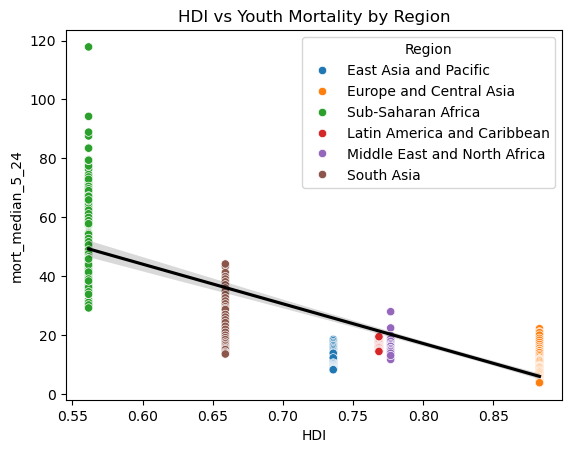

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    hue="Region"
)

sns.regplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    scatter=False,
    color="black"
)

plt.title("HDI vs Youth Mortality by Region")
plt.show()

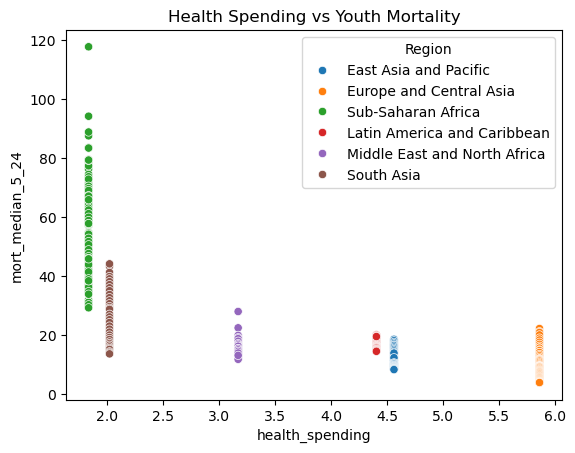

In [88]:
sns.scatterplot(data=df, x="health_spending", y="mort_median_5_24", hue="Region")
plt.title("Health Spending vs Youth Mortality")
plt.show()

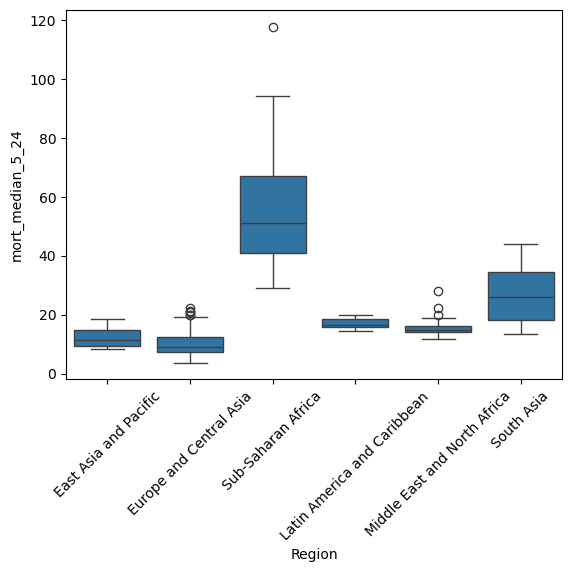

In [89]:
sns.boxplot(data=df, x="Region", y="mort_median_5_24")
plt.xticks(rotation=45)
plt.show()

In [90]:
df.groupby("Region")["mort_median_5_24"].mean().sort_values()

Region
Europe and Central Asia          9.985477
East Asia and Pacific           12.149831
Middle East and North Africa    15.627380
Latin America and Caribbean     16.945456
South Asia                      26.685995
Sub-Saharan Africa              54.545766
Name: mort_median_5_24, dtype: float64

In [91]:
df[["HDI", "mort_median_5_24"]].corr()

,HDI,mort_median_5_24
HDI,1.000000,-0.830574
mort_median_5_24,-0.830574,1.000000


In [92]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["HDI"], df["mort_median_5_24"])

print(corr, p_value)

-0.8305742900201275 2.11441803756972e-99


In [93]:
from scipy.stats import f_oneway

groups = [group["mort_median_5_24"].values for name, group in df.groupby("Region")]

f_stat, p_value = f_oneway(*groups)

print(f_stat, p_value)

276.25730462245025 5.677159046068467e-124


In [94]:
df[["health_spending", "education_spending", "mort_median_5_24"]].corr()

,health_spending,education_spending,mort_median_5_24
health_spending,1.000000,0.987001,-0.771455
education_spending,0.987001,1.000000,-0.741686
mort_median_5_24,-0.771455,-0.741686,1.000000
